# PHASE 1: EXPLORATORY DATA ANALYSIS (EDA)
1. Mean / Median / Mode

In [8]:
%pip install numpy pandas scipy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [9]:
# load the data 
"""
if you running locally then load from local if from collab then load from github links below 
https://github.com/absyd/User_Behavior_Analytics_-_A-B_Testing_Intelligence_System/blob/main/data/Ecommerce_Consumer_Behavior_Analysis_Data.csv
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [10]:
# doenload the data 
!wget https://github.com/absyd/User_Behavior_Analytics_-_A-B_Testing_Intelligence_System/blob/main/data/Ecommerce_Consumer_Behavior_Analysis_Data_fixed.csv

--2026-04-19 09:49:55--  https://github.com/absyd/User_Behavior_Analytics_-_A-B_Testing_Intelligence_System/blob/main/data/Ecommerce_Consumer_Behavior_Analysis_Data_fixed.csv
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘Ecommerce_Consumer_Behavior_Analysis_Data_fixed.csv’

Ecommerce_Consumer_     [ <=>                ]   1.46M  --.-KB/s    in 0.07s   

2026-04-19 09:49:56 (19.6 MB/s) - ‘Ecommerce_Consumer_Behavior_Analysis_Data_fixed.csv’ saved [1529468]



In [10]:
df=pd.read_csv("../data/Ecommerce_Consumer_Behavior_Analysis_Data.csv")


In [11]:
df.head()

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4


In [12]:
df.describe()

,Age,Frequency_of_Purchase,Brand_Loyalty,Product_Rating,Time_Spent_on_Product_Research(hours),Return_Rate,Customer_Satisfaction,Time_to_Decision
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,34.304000,6.945000,3.026000,3.033000,1.013030,0.954000,5.399000,7.547000
std,9.353238,3.147361,1.416803,1.436654,0.791802,0.810272,2.868454,4.035849
min,18.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,26.000000,4.000000,2.000000,2.000000,0.000000,0.000000,3.000000,4.000000
50%,34.500000,7.000000,3.000000,3.000000,1.000000,1.000000,5.000000,8.000000
75%,42.000000,10.000000,4.000000,4.000000,2.000000,2.000000,8.000000,11.000000
max,50.000000,12.000000,5.000000,5.000000,2.000000,2.000000,10.000000,14.000000


In [13]:
purchase_data=df["Purchase_Amount"]

purchase_data

0      $333.80 
1      $222.22 
2      $426.22 
3      $101.31 
4      $211.70 
         ...   
995    $463.67 
996     $69.78 
997    $453.37 
998    $106.15 
999    $378.47 
Name: Purchase_Amount, Length: 1000, dtype: str

In [15]:
df['Purchase_Amount_Float'] = df['Purchase_Amount'].str.replace('$', '').str.replace(',', '').astype(float)

In [16]:
df.head()

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision,Purchase_Amount_Float
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2,333.80
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6,222.22
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3,426.22
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10,101.31
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4,211.70


### 1. Mean / Median / Mode

In [17]:
data = df['Purchase_Amount_Float']

mean = np.mean(data)
median = np.median(data)
mode = stats.mode(data)

print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Mode: {mode}")

Mean: 275.06388
Median: 276.16499999999996
Mode: ModeResult(mode=np.float64(178.04), count=np.int64(2))



**Based on the mean (275.06) and median (276.16), it appears that the distribution is slightly skewed to the right. The mode (178.04) suggests that the distribution is bimodal or has a high concentration of values around 178.04.**

### 2. Standard Deviation

In [19]:
std = np.std(data)
print(f"Standard deviation: {std}")

Standard deviation: 131.46721509009615


Standard deviation: 131.5 (131.46721509009615)
This indicates that the user behavior is not consistent.

### 3. Skewness & Kurtosis

In [20]:
from scipy.stats import skew, kurtosis

sk = skew(data)
kt = kurtosis(data)
print(f"Skewness: {sk}")
print(f"Kurtosis: {kt}")

Skewness: -0.006902856307578828
Kurtosis: -1.212152209002787


Skew > 0 indicates a few users who spend a lot. High kurtosis indicates extreme outliers. These outliers could be fraudulent or represent a select group of users (e.g., VIPs).

## DISTRIBUTION ANALYSIS

### 4. Normal Distribution

<Axes: xlabel='Purchase_Amount_Float', ylabel='Count'>

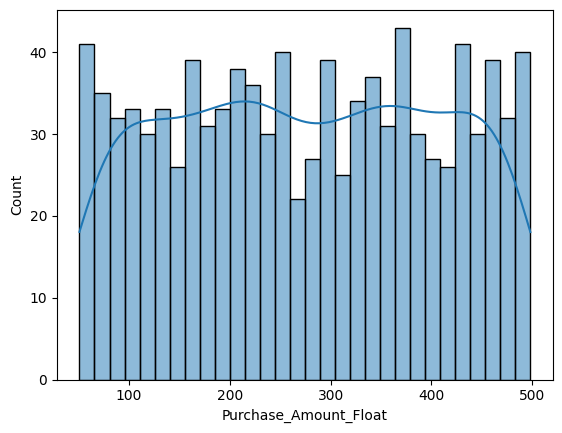

In [24]:
import seaborn as sns
sns.histplot(data, kde=True, bins=30)

### 5. Outliers Detection

In [25]:
z_scores = (data - mean) / std

outliers = data[np.abs(z_scores) > 3]
outliers

Series([], Name: Purchase_Amount_Float, dtype: float64)

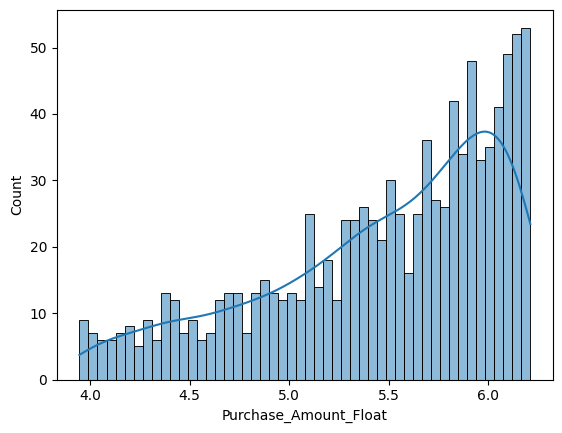

In [28]:
# apply log transformation and visualize
log_data = np.log1p(data)
fig, ax = plt.subplots()
sns.histplot(log_data, ax=ax, bins=50, kde=True)
plt.show()


## PHASE 4: A/B TESTING SYSTEM

In [30]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Income_Level', 'Marital_Status',
       'Education_Level', 'Occupation', 'Location', 'Purchase_Category',
       'Purchase_Amount', 'Frequency_of_Purchase', 'Purchase_Channel',
       'Brand_Loyalty', 'Product_Rating',
       'Time_Spent_on_Product_Research(hours)', 'Social_Media_Influence',
       'Discount_Sensitivity', 'Return_Rate', 'Customer_Satisfaction',
       'Engagement_with_Ads', 'Device_Used_for_Shopping', 'Payment_Method',
       'Time_of_Purchase', 'Discount_Used', 'Customer_Loyalty_Program_Member',
       'Purchase_Intent', 'Shipping_Preference', 'Time_to_Decision',
       'Purchase_Amount_Float'],
      dtype='str')

### Discount Experiment 
- **Hypothesis**: "Giving discounts increases purchase amount"
- **Control**: no discount
- **Treatment**: discount used

In [36]:
# 🎯 A/B TESTING ANALYSIS: DISCOUNT IMPACT ON PURCHASE BEHAVIOR

# Split data into control (no discount) and treatment (discount used) groups
control = df[df['Discount_Used'] == 0]['Purchase_Amount_Float']
treatment = df[df['Discount_Used'] == 1]['Purchase_Amount_Float']

# 📊 Sample Overview
print("=" * 60)
print("🔬 A/B Test Analysis: Discount Effect on Purchase Amount")
print("=" * 60)
print(f"📋 Control Group (No Discount):   {len(control):,} observations")
print(f"🎯 Treatment Group (Discount):    {len(treatment):,} observations")
print(f"📈 Sample Size Ratio:              {len(treatment)/len(control):.2f}")

# 📈 Group Statistics
print("\n📊 Descriptive Statistics:")
print("-" * 40)
print(f"Control Group:   Mean = ${control.mean():.2f}, Std = ${control.std():.2f}")
print(f"Treatment Group: Mean = ${treatment.mean():.2f}, Std = ${treatment.std():.2f}")

# 🔬 Statistical Testing
t_stat, p_value = stats.ttest_ind(control, treatment)

print(f"\n🧪 T-Test Results:")
print("-" * 20)
print(f"T-statistic:     {t_stat:.4f}")
print(f"P-value:         {p_value:.4f}")

# 📋 Hypothesis Testing Interpretation
alpha = 0.05
print(f"\n🎯 Hypothesis Test (α = {alpha}):")
print("-" * 30)

if p_value < alpha:
    print(f"✅ Result: SIGNIFICANT DIFFERENCE DETECTED")
    print(f"   P-value ({p_value:.4f}) < {alpha}")
    print("   🎉 REJECT null hypothesis - discount had a statistically significant effect!")
    
    # Practical significance
    effect_size = (treatment.mean() - control.mean()) / control.std()
    print(f"   📊 Effect Size (Cohen's d): {effect_size:.3f}")
    
    if abs(effect_size) < 0.2:
        print("   💡 Effect size: Small")
    elif abs(effect_size) < 0.5:
        print("   💡 Effect size: Medium")
    else:
        print("   💡 Effect size: Large")
        
else:
    print(f"❌ Result: NO SIGNIFICANT DIFFERENCE")
    print(f"   P-value ({p_value:.4f}) ≥ {alpha}")
    print("   🤷 Fail to reject null hypothesis - no significant effect detected")

# 📏 Confidence Interval Analysis
confidence = 0.95
mean_diff = treatment.mean() - control.mean()
std_error = stats.sem(treatment)

ci = stats.t.interval(confidence, len(treatment)-1, loc=mean_diff, scale=std_error)

print(f"\n📏 Mean Difference Analysis:")
print("-" * 30)
print(f"Mean Difference:           ${mean_diff:.2f}")
print(f"{int(confidence*100)}% Confidence Interval:  [${ci[0]:.2f}, ${ci[1]:.2f}]")

if ci[0] > 0:
    print("💰 Interpretation: Discounts INCREASE purchase amounts")
elif ci[1] < 0:
    print("💸 Interpretation: Discounts DECREASE purchase amounts")
else:
    print("📊 Interpretation: Effect uncertain - interval includes zero")

# 🎲 Chi-Square Test for Categorical Analysis
print(f"\n🎲 Chi-Square Test: Device vs Conversion Analysis")
print("-" * 50)

# Create contingency table
contingency_table = pd.crosstab(df['Device_Used_for_Shopping'], df['Discount_Used'])
print("Contingency Table:")
print(contingency_table)

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Results:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value:              {p_chi:.4f}")
print(f"Degrees of freedom:   {dof}")

if p_chi < alpha:
    print("✅ Significant association between device and discount usage")
else:
    print("❌ No significant association between device and discount usage")

# 🎯 Business Insights Summary
print(f"\n🎯 BUSINESS INSIGHTS SUMMARY")
print("=" * 40)
print(f"📊 Discount Impact: {'SIGNIFICANT' if p_value < alpha else 'NOT SIGNIFICANT'}")
print(f"💰 Revenue Impact:   ${mean_diff:.2f} per transaction")
print(f"📱 Device Analysis:  {'ASSOCIATED' if p_chi < alpha else 'INDEPENDENT'} with discount usage")

if p_value < alpha:
    lift_percentage = (mean_diff / control.mean()) * 100
    print(f"🚀 Revenue Lift:     {lift_percentage:.1f}% increase with discounts")

🔬 A/B Test Analysis: Discount Effect on Purchase Amount
📋 Control Group (No Discount):   479 observations
🎯 Treatment Group (Discount):    521 observations
📈 Sample Size Ratio:              1.09

📊 Descriptive Statistics:
----------------------------------------
Control Group:   Mean = $276.23, Std = $131.95
Treatment Group: Mean = $273.99, Std = $131.27

🧪 T-Test Results:
--------------------
T-statistic:     0.2686
P-value:         0.7883

🎯 Hypothesis Test (α = 0.05):
------------------------------
❌ Result: NO SIGNIFICANT DIFFERENCE
   P-value (0.7883) ≥ 0.05
   🤷 Fail to reject null hypothesis - no significant effect detected

📏 Mean Difference Analysis:
------------------------------
Mean Difference:           $-2.24
95% Confidence Interval:  [$-13.54, $9.06]
📊 Interpretation: Effect uncertain - interval includes zero

🎲 Chi-Square Test: Device vs Conversion Analysis
--------------------------------------------------
Contingency Table:
Discount_Used             False  True 
Devic

<Axes: xlabel='Purchase_Amount_Float', ylabel='Count'>

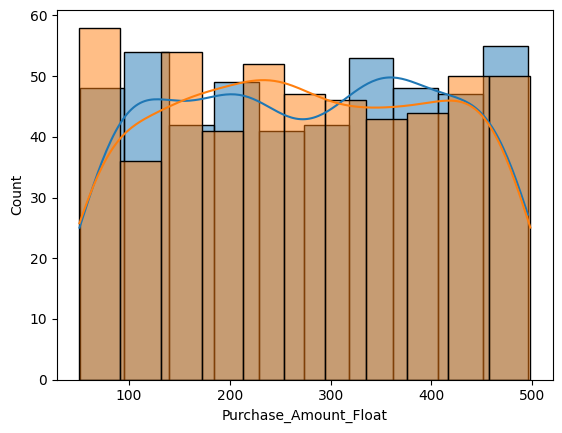

In [33]:
sns.histplot(control, kde=True)
sns.histplot(treatment, kde=True)


In [39]:
# 🎯 A/B TESTING ANALYSIS: LOYALTY PROGRAM IMPACT ON PURCHASE BEHAVIOR

# Split data into control (no loyalty) and treatment (loyalty member) groups
control = df[df['Customer_Loyalty_Program_Member'] == 0]['Purchase_Amount_Float']
treatment = df[df['Customer_Loyalty_Program_Member'] == 1]['Purchase_Amount_Float']

# 📊 Sample Overview
print("=" * 60)
print("🔬 A/B Test Analysis: Loyalty Program Impact on Purchase Amount")
print("=" * 60)
print(f"📋 Control Group (No Loyalty):   {len(control):,} observations")
print(f"🎯 Treatment Group (Loyalty):    {len(treatment):,} observations")
print(f"📈 Sample Size Ratio:              {len(treatment)/len(control):.2f}")

# 📈 Group Statistics
print("\n📊 Descriptive Statistics:")
print("-" * 40)
print(f"Control Group:   Mean = ${control.mean():.2f}, Std = ${control.std():.2f}")
print(f"Treatment Group: Mean = ${treatment.mean():.2f}, Std = ${treatment.std():.2f}")

# 🔬 Statistical Testing
t_stat, p_value = stats.ttest_ind(control, treatment)

print(f"\n🧪 T-Test Results:")
print("-" * 20)
print(f"T-statistic:     {t_stat:.4f}")
print(f"P-value:         {p_value:.4f}")

# 📋 Hypothesis Testing Interpretation
alpha = 0.05
print(f"\n🎯 Hypothesis Test (α = {alpha}):")
print("-" * 30)

if p_value < alpha:
    print(f"✅ Result: SIGNIFICANT DIFFERENCE DETECTED")
    print(f"   P-value ({p_value:.4f}) < {alpha}")
    print("   🎉 REJECT null hypothesis - loyalty program had a statistically significant effect!")
    
    # Practical significance
    effect_size = (treatment.mean() - control.mean()) / control.std()
    print(f"   📊 Effect Size (Cohen's d): {effect_size:.3f}")
    
    if abs(effect_size) < 0.2:
        print("   💡 Effect size: Small")
    elif abs(effect_size) < 0.5:
        print("   💡 Effect size: Medium")
    else:
        print("   💡 Effect size: Large")
        
else:
    print(f"❌ Result: NO SIGNIFICANT DIFFERENCE")
    print(f"   P-value ({p_value:.4f}) ≥ {alpha}")
    print("   🤷 Fail to reject null hypothesis - no significant effect detected")

# 📏 Confidence Interval Analysis
confidence = 0.95
mean_diff = treatment.mean() - control.mean()
std_error = stats.sem(treatment)

ci = stats.t.interval(confidence, len(treatment)-1, loc=mean_diff, scale=std_error)

print(f"\n📏 Mean Difference Analysis:")
print("-" * 30)
print(f"Mean Difference:           ${mean_diff:.2f}")
print(f"{int(confidence*100)}% Confidence Interval:  [${ci[0]:.2f}, ${ci[1]:.2f}]")

if ci[0] > 0:
    print("💰 Interpretation: Loyalty members SPEND MORE per transaction")
elif ci[1] < 0:
    print("💸 Interpretation: Loyalty members SPEND LESS per transaction")
else:
    print("📊 Interpretation: Effect uncertain - interval includes zero")

# 🎲 Chi-Square Test for Categorical Analysis
print(f"\n🎲 Chi-Square Test: Loyalty Status vs Device Usage")
print("-" * 50)

# Create contingency table
contingency_table = pd.crosstab(df['Device_Used_for_Shopping'], df['Customer_Loyalty_Program_Member'])
print("Contingency Table:")
print(contingency_table)

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Results:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value:              {p_chi:.4f}")
print(f"Degrees of freedom:   {dof}")

if p_chi < alpha:
    print("✅ Significant association between loyalty status and device usage")
else:
    print("❌ No significant association between loyalty status and device usage")

# 🎯 Business Insights Summary
print(f"\n🎯 LOYALTY PROGRAM BUSINESS INSIGHTS")
print("=" * 40)
print(f"📊 Program Impact:    {'SIGNIFICANT' if p_value < alpha else 'NOT SIGNIFICANT'}")
print(f"💰 Revenue Impact:    ${mean_diff:.2f} per transaction")
print(f"📱 Device Analysis:   {'ASSOCIATED' if p_chi < alpha else 'INDEPENDENT'} with loyalty status")

if p_value < alpha:
    lift_percentage = (mean_diff / control.mean()) * 100
    print(f"🚀 Revenue Lift:      {lift_percentage:.1f}% increase with loyalty membership")
    
    # Additional loyalty insights
    print(f"\n💡 LOYALTY PROGRAM RECOMMENDATIONS:")
    if lift_percentage > 10:
        print("   🎯 Strong ROI - Consider expanding program benefits")
    elif lift_percentage > 5:
        print("   📈 Positive ROI - Optimize current program structure")
    else:
        print("   🔍 Modest impact - Evaluate program costs vs benefits")
        
    # Member penetration analysis
    penetration_rate = len(treatment) / (len(control) + len(treatment)) * 100
    print(f"   👥 Member Penetration: {penetration_rate:.1f}% of customer base")
    
    if penetration_rate < 30:
        print("   📢 Consider marketing campaigns to increase membership")
    elif penetration_rate > 70:
        print("   🎉 High adoption - focus on retention and tier upgrades")
    else:
        print("   ⚖️ Balanced adoption - maintain current acquisition strategy")

# 📊 Additional Loyalty Metrics
print(f"\n📊 ADDITIONAL LOYALTY METRICS")
print("-" * 30)

# Purchase frequency analysis
if 'Frequency_of_Purchase' in df.columns:
    control_freq = df[df['Customer_Loyalty_Program_Member'] == 0]['Frequency_of_Purchase']
    treatment_freq = df[df['Customer_Loyalty_Program_Member'] == 1]['Frequency_of_Purchase']
    
    print(f"Purchase Frequency:")
    print(f"  Non-members: {control_freq.mean():.1f} purchases/period")
    print(f"  Members:     {treatment_freq.mean():.1f} purchases/period")
    print(f"  Difference:  {treatment_freq.mean() - control_freq.mean():.1f} (+{((treatment_freq.mean() - control_freq.mean())/control_freq.mean()*100):.1f}%)")

# Customer satisfaction analysis
if 'Customer_Satisfaction' in df.columns:
    control_sat = df[df['Customer_Loyalty_Program_Member'] == 0]['Customer_Satisfaction']
    treatment_sat = df[df['Customer_Loyalty_Program_Member'] == 1]['Customer_Satisfaction']
    
    print(f"\nCustomer Satisfaction:")
    print(f"  Non-members: {control_sat.mean():.1f}/10")
    print(f"  Members:     {treatment_sat.mean():.1f}/10")
    print(f"  Difference:  {treatment_sat.mean() - control_sat.mean():.1f}")

🔬 A/B Test Analysis: Loyalty Program Impact on Purchase Amount
📋 Control Group (No Loyalty):   509 observations
🎯 Treatment Group (Loyalty):    491 observations
📈 Sample Size Ratio:              0.96

📊 Descriptive Statistics:
----------------------------------------
Control Group:   Mean = $288.37, Std = $130.63
Treatment Group: Mean = $261.27, Std = $131.17

🧪 T-Test Results:
--------------------
T-statistic:     3.2737
P-value:         0.0011

🎯 Hypothesis Test (α = 0.05):
------------------------------
✅ Result: SIGNIFICANT DIFFERENCE DETECTED
   P-value (0.0011) < 0.05
   🎉 REJECT null hypothesis - loyalty program had a statistically significant effect!
   📊 Effect Size (Cohen's d): -0.208
   💡 Effect size: Medium

📏 Mean Difference Analysis:
------------------------------
Mean Difference:           $-27.11
95% Confidence Interval:  [$-38.74, $-15.47]
💸 Interpretation: Loyalty members SPEND LESS per transaction

🎲 Chi-Square Test: Loyalty Status vs Device Usage
-------------------

🔥 PHASE 6: BUILD DASHBOARD (VERY IMPORTANT)

Use Streamlit

Show:
Distribution plots
Mean, median, std
Skewness, kurtosis
Outliers (Z-score)
A/B test results
p-value decisions